# Notebook 2 : Diamants 💎

In [34]:
# Décommenter la ligne suivante pour installer les dépendances
# %pip install jupyter_bokeh nbconvert panel watchfiles

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import panel as pn
import plotly.graph_objects as go
import plotly.express as px

pn.extension("plotly", "tabulator")

Les données utilisées pour cette application correspondent à des caractéristiques de 53940 diamants :

- `price` : prix en dollars américains,
- `carat` : masse du diamant,
- `cut` : qualité de la taille,
- `color` : couleur allant de `D` (meilleure) à `J` (pire),
- `clarity` : code de clarté du diamant,
- `x`, `y`, `z` : dimensions du diamant.

## Préliminaires

1. Écrire une fonction `get_data` sans argument qui retourne les données contenues dans le fichier `data/diamonds.csv` sous la forme d'un DataFrame Pandas. Cette fontion a vocation à être appelée plusieurs fois avec le même résultat attendu, elle pourra donc être décorée avec `pn.cache`.

In [36]:
@pn.cache
def get_data():
    df = pd.read_csv("data/diamonds.csv")
    return df

2. Utiliser la méthode `value_counts` de Pandas pour compter les effectifs de diamants selon la variable `cut`.

In [37]:
df = get_data()
cut_counts = df.cut.value_counts()
cut_counts

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

 3. Utiliser la fonction `pie` de Matplotlib (voir [la documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html)) pour visualiser les effectifs de la question précédente sous la forme d'un camembert.

([<matplotlib.patches.Wedge at 0x7fe4e929ca50>,
 [Text(0.3414415318010835, 1.0456661419216604, 'Ideal'),
  Text(-1.0837708009350322, -0.1882574063367466, 'Premium'),
  Text(0.11867640474968727, -1.0935794031325246, 'Very Good'),
  Text(0.9790873764255467, -0.5013859883604049, 'Good'),
  Text(1.0951675106156111, -0.1029957459898499, 'Fair')])

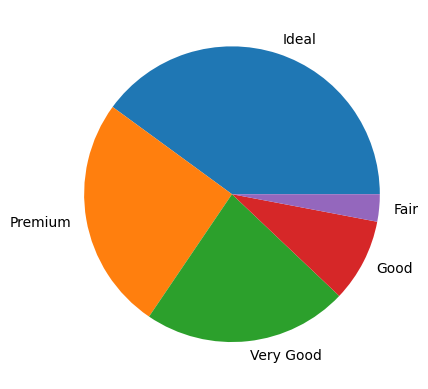

In [38]:
plt.pie(cut_counts, labels=cut_counts.index)

4. Utiliser la fonction `scatter` de Matplotlib (voir [la documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)) pour afficher le nuage de points associé à la variable `price` en fonction de la variable `carat`. Colorer les points en fonction de la variable `color` et faire apparaître la légende correspondante sur le graphique.

In [39]:
color_counts = df.color.value_counts()
color_counts

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

/tmp/ipykernel_62643/4145523126.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


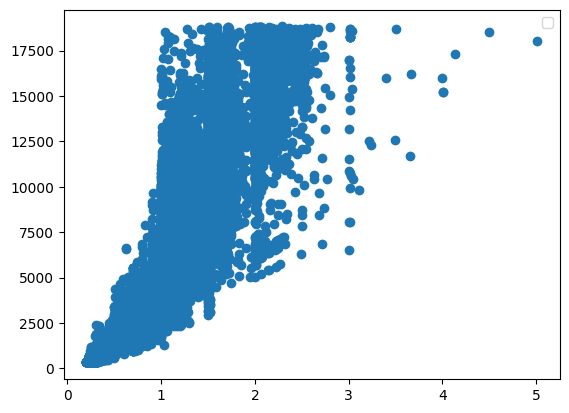

In [44]:
fig, ax = plt.subplots()

ax.legend()
ax.scatter(df.carat,df.price)

5. Utiliser la fonction `scatter` de Plotly (voir [la documentation](https://plotly.com/python-api-reference/generated/plotly.express.scatter)) pour afficher le nuage de points associé à la variable `price` en fonction de la variable `carat`. Colorer les points en fonction de la variable `color`. Noter que la légende est directement intégrée au graphique et que ce dernier offre plusieurs possibilités d'interaction (zoom, filtre, ...).

## Filtre des diamants

6. Créer un selecteur multiple `colors` de type `MultiChoice` (voir [la documentation](https://panel.holoviz.org/reference/widgets/MultiChoice.html)) pour sélectionner certaines couleurs des diamants du jeu de données (toutes les couleurs devront être sélectionnées par défaut). Afficher l'objet dans le notebook avec un nom (`name`) associé. Quel est le contenu et le type de l'attribut `value` de cet objet ?

7. Écrire une fonction `get_colored_diamonds` avec un argument `colors` contenant une liste de couleurs de diamants qui retourne les données obtenues avec `get_data` filtrées selon cette liste de couleurs. Cette fontion a vocation à être appelée plusieurs fois avec le même résultat attendu, elle pourra donc être décorée avec `pn.cache`.

8. À l'aide de `pn.bind`, lier la fonction `get_colored_diamonds` à la valeur du widget `colors` de la question 6 pour le paramètre `colors`. Placer le résultat dans un widget `Tabulator` (voir [la documentation](https://panel.holoviz.org/reference/widgets/Tabulator.html)) qui sera affiché dans le notebook. Masquer l'index dans le `Tabulator` et désactiver l'édition (paramètre `disabled`). Limiter le nombre de lignes par page à `10`. Faire varier la valeur du widget pour visualiser l'interaction.

## Fonctions graphiques

9. Écrire une fonction `get_pie` avec un argument `colors` qui retourne l'objet graphique Matplotlib du camembert de la question 3 pour les données filtrées par couleur selon `colors`. Penser à fermer la figure avec `plt.close` avant de la retourner pour éviter les fuites de mémoire.

10. Écrire une fonction `get_scatter_matplotlib` avec les arguments `colors` et `title` qui retourne l'objet graphique Matplotlib du nuage de points de la question 4 pour les données filtrées par couleur selon `colors` avec un titre donné par `title`. Penser à fermer la figure avec `plt.close` avant de la retourner pour éviter les fuites de mémoire.

11. Écrire une fonction `get_scatter_plotly` avec les arguments `colors` et `title` qui retourne l'objet graphique Plotly du nuage de points de la question 5 pour les données filtrées par couleur selon `colors` avec un titre donné par `title`.

## Application web

Nous pouvons maintenant mettre en place une application web qui pourra être démarrée avec la commande suivante (l'option `--allow-websocket-origin` n'est nécessaire que dans Onyxia) :
```{bash}
panel serve --autoreload --show --allow-websocket-origin=$(echo $VSCODE_PROXY_URI | cut -d '/' -f 3) notebooks/02_diamants.ipynb
```

Les questions suivantes ont pour objet d'enrichir l'application au fur et à mesure. Il ne faut donc pas recréer une nouvelle application pour chaque question mais faire évoluer le code étape par étape. Il peut être utile d'ajouter de nouvelles cellules de code si besoin.

12. Mettre en forme une application à l'aide du modèle `FastListTemplate` (voir [la documentation](https://panel.holoviz.org/reference/templates/FastListTemplate.html)) avec le widget `colors` et un widget `title` de type `TextInput` (voir [la documentation](https://panel.holoviz.org/reference/widgets/TextInput.html)) dans la barre latérale et une zone principale telle que :
  - le widget `Tabulator` des données filtrées se trouve en haut à gauche,
  - le *pane* contenant le camembert obtenu avec la fonction `get_pie` se trouve en haut à droite,
  - le *pane* contenant le graphique Matplotlib obtenu avec la fonction `get_scatter_matplotlib` occupe la partie inférieure.

13. Utiliser les paramètres `height` et `sizing_mode` du *panes* contenant le camembert pour adapter sa taille. Remarquer l'aspect peu satisfaisant de l'affichage des graphiques Matplotlib.

14. Remplacer le *pane* du nuage de points Matplotlib par un *pane* adapté à l'objet graphique retourné par `get_scatter_plotly`. Remarquer comment l'aspect du graphique Plotly s'adapte à la taille de la fenêtre.

15. Ajouter un *pane* de type `Markdown` (voir [la documentation](https://panel.holoviz.org/reference/panes/Markdown.html)) en haut à droite de l'application contenant un texte mis en forme pour afficher les moyennes et les variances des variables quantitatives du jeu de données filtré selon `colors`.